In [29]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from tqdm.autonotebook import tqdm
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


In [30]:
STN_DATA_path_PD = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_PD.yaml')
STN_DATA_path_std_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_std_DBS.yaml')
STN_DATA_path_sector_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_sector_DBS.yaml')
DEL_LIM_ARR = [0.1, 0.2, 0.5, 1.0]
FILE_PATHS = [STN_DATA_path_PD, STN_DATA_path_std_DBS, STN_DATA_path_sector_DBS]
TYPE = ['PD', 'STD_DBS', 'SECTOR_DBS']
LAT_STRENGTH = 0.0475 
VAR_ARR = [0.01, 0.04, 0.39] 

In [31]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'restless_bandits', 'params.yaml')
params = load_yaml(yaml_path)

In [32]:
# ENV params
NUM_ARMS = params['NUM_ARMS']
MEAN_REWARD = np.array([40,40,60,80])
REW_STD = np.array([4,4,4,4])
SCALING_FACTOR = params['SCALING_FACTOR']

# Training params
TRIALS = params['TRIALS']
EPOCHS = 100 #params['EPOCHS']
BINS = params['NUM_BINS']
LR = params['LR']


LAMBDA_DECAY = 0.9836
THETA = 50
DIFFUSIVE_NOISE_MEAN = 0
DIFFUSIVE_NOISE_STD = 2.8


ARM_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)
PROB_OPTIMAL_MONITOR = defaultdict(dict)
MEAN_PROB_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)

DP_MONITOR = defaultdict(dict)
TRUE_MEAN_REWARDS_MONITOR = defaultdict(dict)
CHOICE_VARIABILITY_METRICS_MONITOR = defaultdict(dict)
Q_ERROR_METRICS_MONITOR = defaultdict(dict)


In [33]:
env = RestlessBanditsEnv(num_arms=NUM_ARMS, 
                         mean_reward=MEAN_REWARD/SCALING_FACTOR, 
                         std = REW_STD/SCALING_FACTOR,
                         lambda_decay = LAMBDA_DECAY, 
                         theta = THETA/SCALING_FACTOR, 
                         diffusive_noise_std = DIFFUSIVE_NOISE_STD/SCALING_FACTOR, 
                         diffusive_noise_mean = DIFFUSIVE_NOISE_MEAN/SCALING_FACTOR)


In [34]:
# Calculate average Prob of best arm picking every bin
def max_rew_arm(x:dict):
    rew_list = np.array([x[key][0] for key in list(x.keys())])
    return np.argmax(rew_list)

def process_epoch_optimal_arm(x:list):
    optimal_arm = [max_rew_arm(x[trail]) for trail in range(len(x)-1)]
    return optimal_arm

In [35]:

# ==================================================
# Choice variability and Q-value error helper functions
# ==================================================

def _to_numpy(x):
    """Convert torch tensors / arrays to numpy."""
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _to_scalar(x):
    """Convert tensor/array/list scalar to Python float."""
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    arr = np.asarray(x)
    return float(arr.reshape(-1)[0])


def nested_defaultdict_to_dict(d):
    """Recursively convert defaultdict/dict to normal dict before pickle saving."""
    if isinstance(d, defaultdict):
        d = dict(d)
    if isinstance(d, dict):
        return {k: nested_defaultdict_to_dict(v) for k, v in d.items()}
    return d


def compute_choice_variability_metrics(arm_chosen_monitor, n_arms, window_size=15, alpha=0.7):
    """
    Computes choice variability from action sequence.

    Entropy: normalized action entropy within a rolling window.
    Switching: fraction of trial-to-trial action changes within a rolling window.
    Combined: alpha * entropy + (1 - alpha) * switching.
    """
    choices = _to_numpy(arm_chosen_monitor).astype(int)

    if choices.ndim > 2:
        choices = np.squeeze(choices)

    if choices.ndim == 1:
        choices = choices[None, :]

    epochs, trials = choices.shape
    window_size = min(window_size, trials)

    entropy_by_epoch = []
    switching_by_epoch = []
    combined_by_epoch = []

    for e in range(epochs):
        epoch_choices = choices[e]

        entropy_windows = []
        switching_windows = []
        combined_windows = []

        for start in range(0, trials - window_size + 1):
            window_choices = epoch_choices[start:start + window_size]

            counts = np.bincount(window_choices, minlength=n_arms).astype(float)
            probs = counts / np.sum(counts)
            probs_nonzero = probs[probs > 0]

            if n_arms > 1:
                entropy = -np.sum(probs_nonzero * np.log(probs_nonzero)) / np.log(n_arms)
            else:
                entropy = 0.0

            if window_size > 1:
                switching = np.mean(window_choices[1:] != window_choices[:-1])
            else:
                switching = 0.0

            combined = alpha * entropy + (1 - alpha) * switching

            entropy_windows.append(entropy)
            switching_windows.append(switching)
            combined_windows.append(combined)

        entropy_by_epoch.append(np.mean(entropy_windows))
        switching_by_epoch.append(np.mean(switching_windows))
        combined_by_epoch.append(np.mean(combined_windows))

    entropy_by_epoch = np.asarray(entropy_by_epoch)
    switching_by_epoch = np.asarray(switching_by_epoch)
    combined_by_epoch = np.asarray(combined_by_epoch)

    return {
        "window_size": window_size,
        "alpha_entropy": alpha,

        "mean_entropy": float(np.mean(entropy_by_epoch)),
        "mean_switching": float(np.mean(switching_by_epoch)),
        "mean_combined_variability": float(np.mean(combined_by_epoch)),

        "entropy_by_epoch": entropy_by_epoch,
        "switching_by_epoch": switching_by_epoch,
        "combined_variability_by_epoch": combined_by_epoch,
    }


def convert_dp_monitor_to_array(dp_monitor, num_arms):
    """
    Converts dp_monitor into shape:
        epochs x trials x arms

    Expected format in these notebooks:
        dp_monitor[arm].shape = (epochs, trials, 1)
    """
    if isinstance(dp_monitor, dict):
        q_list = []
        for arm in range(num_arms):
            if arm in dp_monitor:
                arm_key = arm
            elif np.int64(arm) in dp_monitor:
                arm_key = np.int64(arm)
            elif str(arm) in dp_monitor:
                arm_key = str(arm)
            else:
                raise KeyError(f"Arm {arm} not found in dp_monitor keys: {list(dp_monitor.keys())}")

            q_arm = _to_numpy(dp_monitor[arm_key])
            q_arm = np.squeeze(q_arm)

            if q_arm.ndim != 2:
                raise ValueError(f"Expected dp_monitor[{arm_key}] to become 2D after squeeze, got shape {q_arm.shape}")

            q_list.append(q_arm)

        q_values = np.stack(q_list, axis=-1)

    else:
        q_values = _to_numpy(dp_monitor)
        q_values = np.squeeze(q_values)

        if q_values.ndim != 3:
            raise ValueError(f"Expected dp_monitor array to be 3D, got shape {q_values.shape}")

        # If shape is arms x epochs x trials, convert to epochs x trials x arms
        if q_values.shape[0] == num_arms:
            q_values = np.transpose(q_values, (1, 2, 0))

    return q_values.astype(float)


def convert_arm_tracker_to_true_means(arm_tracker_full, num_arms, trials):
    """
    Converts restless-bandit arm_tracker_full into true reward means.

    Output shape:
        epochs x trials x arms

    arm_tracker_full[epoch][trial][arm][0] contains the true mean reward
    on the same normalized scale used by the environment.
    """
    n_epochs = len(arm_tracker_full)
    true_means = np.full((n_epochs, trials, num_arms), np.nan, dtype=float)

    for e in range(n_epochs):
        epoch_tracker = arm_tracker_full[e]
        n_t = min(trials, len(epoch_tracker))

        for t in range(n_t):
            arm_dict = epoch_tracker[t]

            for arm in range(num_arms):
                if arm in arm_dict:
                    arm_key = arm
                elif np.int64(arm) in arm_dict:
                    arm_key = np.int64(arm)
                elif str(arm) in arm_dict:
                    arm_key = str(arm)
                else:
                    continue

                true_means[e, t, arm] = _to_scalar(arm_dict[arm_key][0])

    return true_means


def compute_q_error_metrics(dp_monitor, true_means, arm_chosen_monitor=None, num_arms=None):
    """
    Computes DP/Q-value error by comparing dp_monitor to true restless-bandit means.

    dp_monitor is converted to:
        epochs x trials x arms

    true_means should be:
        epochs x trials x arms
    """
    if num_arms is None:
        num_arms = true_means.shape[-1]

    q_values = convert_dp_monitor_to_array(dp_monitor, num_arms=num_arms)
    true_means = np.asarray(true_means, dtype=float)

    min_epochs = min(q_values.shape[0], true_means.shape[0])
    min_trials = min(q_values.shape[1], true_means.shape[1])

    q_values = q_values[:min_epochs, :min_trials, :]
    true_means = true_means[:min_epochs, :min_trials, :]

    q_error = q_values - true_means

    rmse_by_epoch = np.sqrt(np.nanmean(q_error ** 2, axis=(1, 2)))
    mae_by_epoch = np.nanmean(np.abs(q_error), axis=(1, 2))

    metrics = {
        "mean_q_rmse": float(np.nanmean(rmse_by_epoch)),
        "mean_q_mae": float(np.nanmean(mae_by_epoch)),
        "q_rmse_by_epoch": rmse_by_epoch,
        "q_mae_by_epoch": mae_by_epoch,
    }

    if arm_chosen_monitor is not None:
        choices = _to_numpy(arm_chosen_monitor).astype(int)
        if choices.ndim > 2:
            choices = np.squeeze(choices)
        if choices.ndim == 1:
            choices = choices[None, :]

        choices = choices[:min_epochs, :min_trials]

        selected_errors = []
        for e in range(min_epochs):
            for t in range(min_trials):
                chosen_arm = int(choices[e, t])
                if 0 <= chosen_arm < q_values.shape[-1]:
                    selected_errors.append(abs(q_values[e, t, chosen_arm] - true_means[e, t, chosen_arm]))

        metrics["mean_selected_abs_value_error"] = float(np.nanmean(selected_errors))

    return metrics


In [36]:

t = 0
for file_path in tqdm(FILE_PATHS):
    print(f'Running: {TYPE[t]}')

    args = load_yaml(file_path)
    args['lat_strength_stn'] = LAT_STRENGTH

    save_temp_path = os.path.join(project_root, 'temp', 'temp.yaml')
    save_yaml(args, save_temp_path)

    for del_lim in DEL_LIM_ARR:
        reward_monitor, arm_chosen_monitor, avg_counts, ip_monitor, dp_monitor, ep_monitor, arm_tracker_full = train(
            env,
            trails=TRIALS,
            epochs=EPOCHS,
            lr=LR,
            bins=BINS,
            STN_data=save_temp_path,
            d1_amp=1,
            d2_amp=0.00325,
            gpi_threshold=0.3,
            max_gpi_iters=50,
            del_lim=del_lim,
            train_IP=False,
            del_med=None,
            printing=False,
            gpi_mean=1,
            ep_0=0,
            alpha_ep=0.0,
            eta_ep=0.1,
            baseline_ep=0.0,
            track_arms=True
        )

        # ------------------------------------------------------------
        # Store raw monitors
        # ------------------------------------------------------------
        ARM_MONITOR[TYPE[t]][del_lim] = arm_chosen_monitor
        REWARD_MONITOR[TYPE[t]][del_lim] = reward_monitor
        DP_MONITOR[TYPE[t]][del_lim] = dp_monitor
        ARM_TRACKER[TYPE[t]][del_lim] = arm_tracker_full

        # ------------------------------------------------------------
        # Build true reward means for restless bandits
        # Shape: epochs x trials x arms
        # Already on normalized reward scale because the env was initialized
        # with MEAN_REWARD / SCALING_FACTOR.
        # ------------------------------------------------------------
        true_mean_rewards = convert_arm_tracker_to_true_means(
            arm_tracker_full=arm_tracker_full,
            num_arms=NUM_ARMS,
            trials=TRIALS
        )

        TRUE_MEAN_REWARDS_MONITOR[TYPE[t]][del_lim] = true_mean_rewards

        # ------------------------------------------------------------
        # Choice variability and DP/Q-value error metrics
        # ------------------------------------------------------------
        choice_var_metrics = compute_choice_variability_metrics(
            arm_chosen_monitor=arm_chosen_monitor,
            n_arms=NUM_ARMS,
            window_size=15,
            alpha=0.7
        )

        q_error_metrics = compute_q_error_metrics(
            dp_monitor=dp_monitor,
            true_means=true_mean_rewards,
            arm_chosen_monitor=arm_chosen_monitor,
            num_arms=NUM_ARMS
        )

        CHOICE_VARIABILITY_METRICS_MONITOR[TYPE[t]][del_lim] = choice_var_metrics
        Q_ERROR_METRICS_MONITOR[TYPE[t]][del_lim] = q_error_metrics

        # ------------------------------------------------------------
        # Performance: probability of choosing current best arm
        # ------------------------------------------------------------
        OPTIMAL_CHOICE_ARRAY = np.array([
            process_epoch_optimal_arm(ARM_TRACKER[TYPE[t]][del_lim][epoch])
            for epoch in range(len(ARM_TRACKER[TYPE[t]][del_lim]))
        ])

        ACTUAL_CHOICE_ARRAY = np.array(ARM_MONITOR[TYPE[t]][del_lim])
        NUMBER_OF_MATCHES = (OPTIMAL_CHOICE_ARRAY == ACTUAL_CHOICE_ARRAY) * 1
        PROB = np.mean(NUMBER_OF_MATCHES, axis=1)
        mean_prob = np.mean(PROB)

        PROB_OPTIMAL_MONITOR[TYPE[t]][del_lim] = PROB
        MEAN_PROB_MONITOR[TYPE[t]][del_lim] = mean_prob

        print(
            f"del_lim = {del_lim} and type = {TYPE[t]}: "
            f"mean prob of optimal arm = {mean_prob:.4f}, "
            f"entropy+switching = {choice_var_metrics['mean_combined_variability']:.4f}, "
            f"Q-error = {q_error_metrics['mean_q_rmse']:.4f}"
        )

    t += 1


  0%|          | 0/3 [00:00<?, ?it/s]

Running: PD
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.05435816987542625, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

...

del_lim = 0.5 and type = SECTOR_DBS: mean prob of optimal arm = 0.5548, entropy+switching = 0.1885, Q-error = 0.1388
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.3349999999997932, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

del_lim = 1.0 and type = SECTOR_DBS: mean prob of optimal arm = 0.5507, entropy+switching = 0.1902, Q-error = 0.1382


In [37]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
Mean_Probs_PD = [MEAN_PROB_MONITOR[TYPE[0]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Mean_Probs_std_DBS = [MEAN_PROB_MONITOR[TYPE[1]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Mean_Probs_sector_DBS = [MEAN_PROB_MONITOR[TYPE[2]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]

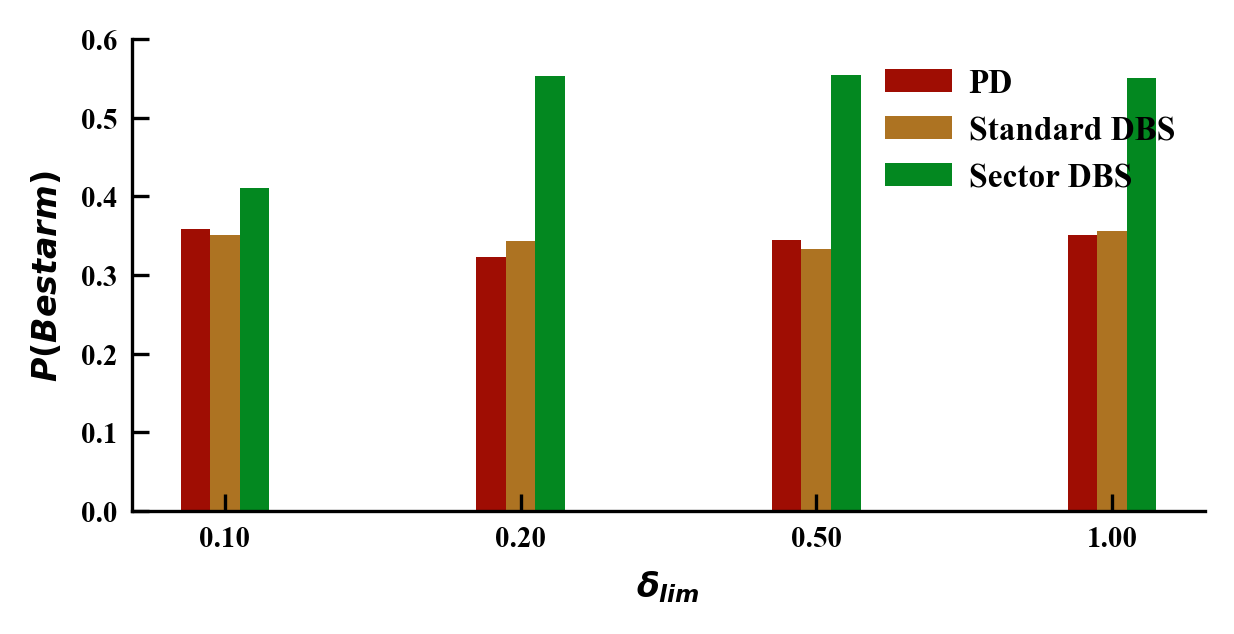

In [38]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}

plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Mean_Probs_PD, width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Mean_Probs_std_DBS, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Mean_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.ylim(0,0.6)
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.show()

In [39]:

# ==================================================
# Save restless-bandit choice-variability and Q-error metrics
# ==================================================

metrics_data = {
    "DEL_LIM_ARR": DEL_LIM_ARR,
    "TYPE": TYPE,
    "LAT_STRENGTH": LAT_STRENGTH,

    "SCALING_FACTOR": SCALING_FACTOR,
    "NUM_ARMS": NUM_ARMS,
    "TRIALS": TRIALS,
    "EPOCHS": EPOCHS,
    "BINS": BINS,
    "LAMBDA_DECAY": LAMBDA_DECAY,
    "THETA": THETA,
    "DIFFUSIVE_NOISE_MEAN": DIFFUSIVE_NOISE_MEAN,
    "DIFFUSIVE_NOISE_STD": DIFFUSIVE_NOISE_STD,

    # Performance
    "MEAN_PROB_MONITOR": nested_defaultdict_to_dict(MEAN_PROB_MONITOR),
    "PROB_OPTIMAL_MONITOR": nested_defaultdict_to_dict(PROB_OPTIMAL_MONITOR),

    # Choice variability = entropy + switching
    "CHOICE_VARIABILITY_METRICS_MONITOR": nested_defaultdict_to_dict(CHOICE_VARIABILITY_METRICS_MONITOR),

    # DP/Q-value error
    "Q_ERROR_METRICS_MONITOR": nested_defaultdict_to_dict(Q_ERROR_METRICS_MONITOR),

    # Raw monitors included so the metric file is self-contained
    "ARM_MONITOR": nested_defaultdict_to_dict(ARM_MONITOR),
    "DP_MONITOR": nested_defaultdict_to_dict(DP_MONITOR),
    "REWARD_MONITOR": nested_defaultdict_to_dict(REWARD_MONITOR),
    "TRUE_MEAN_REWARDS_MONITOR": nested_defaultdict_to_dict(TRUE_MEAN_REWARDS_MONITOR),
}

metrics_file_name = (
    "restless_bandits_choice_q_metrics_lat_"
    + str(LAT_STRENGTH).replace(".", "_")
    + ".pkl"
)

metrics_file_path = os.path.join(
    project_root,
    "simulations",
    "decision_making_tasks",
    "restless_bandits",
    metrics_file_name
)

os.makedirs(os.path.dirname(metrics_file_path), exist_ok=True)

with open(metrics_file_path, "wb") as f:
    pickle.dump(metrics_data, f)

print("Saved restless-bandit metrics file:", metrics_file_path)


Saved restless-bandit metrics file: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/simulations/decision_making_tasks/restless_bandits/restless_bandits_choice_q_metrics_lat_0_0475.pkl


In [40]:
# # saving pickle with lat name
# data = {'DEL_LIM_ARR': DEL_LIM_ARR,
#         'TYPE': TYPE,
#         'ARM_MONITOR': ARM_MONITOR,
#         'LAT_STRENGTH': LAT_STRENGTH,
#         'ARM_TRACKER': ARM_TRACKER,
#         'MEAN_PROB_MONITOR': MEAN_PROB_MONITOR,
#         'PROB_OPTIMAL_MONITOR': PROB_OPTIMAL_MONITOR,
#         'REWARD_MONITOR': REWARD_MONITOR}
# file_name = 'restless_bandits_data_lat_' + str(LAT_STRENGTH).replace('.', '_') + '_2.pkl'
# file_path = os.path.join(project_root, 'simulations', 'decision_making_tasks', 'restless_bandits', file_name)

# with open(file_path, 'wb') as f:
#     pickle.dump(data, f)

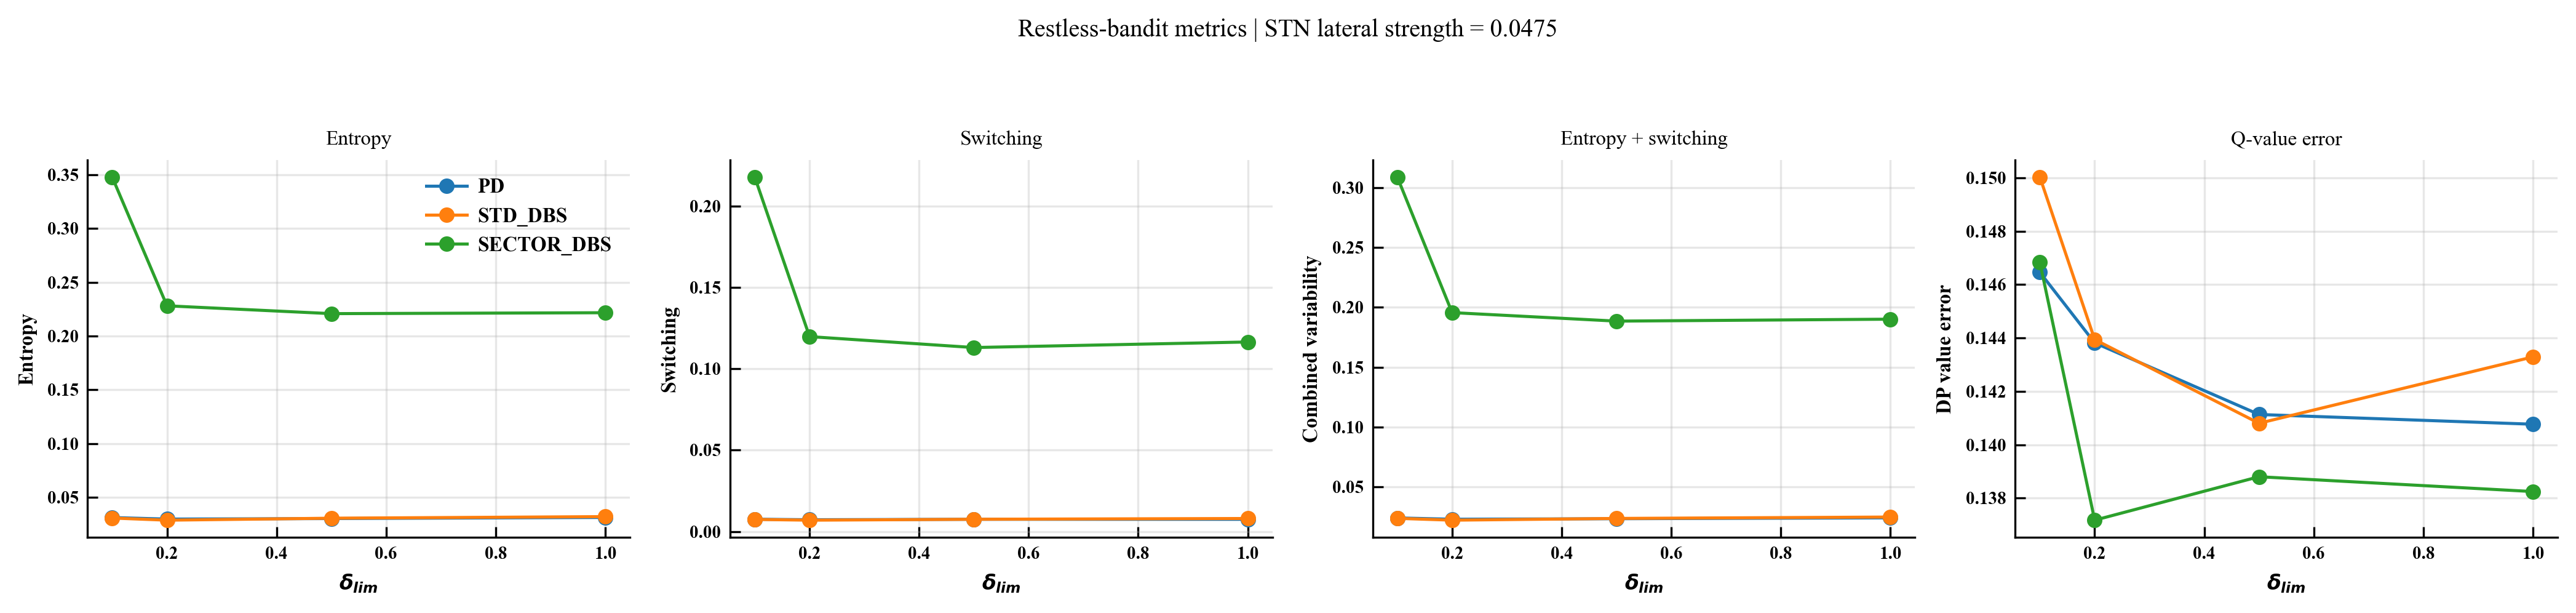

In [41]:

# ==================================================
# Quick line plots: entropy, switching, entropy+switching, and Q-error
# ==================================================

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharex=True)

plot_specs = [
    ("mean_entropy", "Entropy", "Entropy"),
    ("mean_switching", "Switching", "Switching"),
    ("mean_combined_variability", "Entropy + switching", "Combined variability"),
    ("mean_q_rmse", "Q-value error", "DP value error"),
]

for cond in TYPE:
    entropy_vals = [CHOICE_VARIABILITY_METRICS_MONITOR[cond][d]["mean_entropy"] for d in DEL_LIM_ARR]
    switching_vals = [CHOICE_VARIABILITY_METRICS_MONITOR[cond][d]["mean_switching"] for d in DEL_LIM_ARR]
    combined_vals = [CHOICE_VARIABILITY_METRICS_MONITOR[cond][d]["mean_combined_variability"] for d in DEL_LIM_ARR]
    q_vals = [Q_ERROR_METRICS_MONITOR[cond][d]["mean_q_rmse"] for d in DEL_LIM_ARR]

    axes[0].plot(DEL_LIM_ARR, entropy_vals, marker="o", label=cond)
    axes[1].plot(DEL_LIM_ARR, switching_vals, marker="o", label=cond)
    axes[2].plot(DEL_LIM_ARR, combined_vals, marker="o", label=cond)
    axes[3].plot(DEL_LIM_ARR, q_vals, marker="o", label=cond)

for ax, (_, title, ylabel) in zip(axes, plot_specs):
    ax.set_title(title)
    ax.set_xlabel(r"$\delta_{lim}$")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[0].legend(frameon=False)
plt.suptitle(f"Restless-bandit metrics | STN lateral strength = {LAT_STRENGTH}", y=1.08)
plt.tight_layout()
plt.show()


In [42]:
# _1: d2_amp = 0.0035
# _2: d2_amp = 0.003
# _3: d2_amp = 0.003 
# _4: d2_amp = 0.0031
# _5: d2_amp = 0.003 => ran for 100 epochs
# _6: d2_amp = 0.003 => ran for 100 epochs

# _7: d2_amp = 0.00325 => ran for 100 epochs